# Ejercicio 8 - Prueba con fotos propias

Probamos el mejor modelo del laboratorio, la CNN profunda (`cnn_profunda.ipynb`, 98.66% de accuracy en test), con fotos de señas hechas a mano por los integrantes del grupo, guardadas en `fotos_equipo/`. El nombre de cada archivo indica la letra que se hizo y quién la hizo, por ejemplo `a_isa.jpeg` es la letra A hecha por Isa.

In [1]:
from pathlib import Path

import numpy as np
from PIL import Image
from tensorflow import keras

IMG_SIZE = 64

model = keras.models.load_model("models/cnn_profunda.keras")

class_names = np.load("asl-alphabet/processed/asl_64x64_600pc.npz", allow_pickle=True)["class_names"]
class_names = list(class_names)

In [2]:
FOTOS_DIR = Path("fotos_equipo")
fotos = sorted(FOTOS_DIR.glob("*.jpeg")) + sorted(FOTOS_DIR.glob("*.jpg")) + sorted(FOTOS_DIR.glob("*.png"))

print(f"{len(fotos)} fotos encontradas")

def parse_nombre(path):
    stem = path.stem
    if "_" in stem:
        letra, integrante = stem.split("_", 1)
    else:
        letra, integrante = stem, "equipo"
    return letra.upper(), integrante

for f in fotos:
    print(f.name, "->", parse_nombre(f))

15 fotos encontradas
a_isa.jpeg -> ('A', 'isa')
b_isa.jpeg -> ('B', 'isa')
c_isa.jpeg -> ('C', 'isa')
d_isa.jpeg -> ('D', 'isa')
e_isa.jpeg -> ('E', 'isa')
f.jpeg -> ('F', 'equipo')
g.jpeg -> ('G', 'equipo')
h.jpeg -> ('H', 'equipo')
i.jpeg -> ('I', 'equipo')
j.jpeg -> ('J', 'equipo')
k_nils.jpeg -> ('K', 'nils')
l_nils.jpeg -> ('L', 'nils')
m_nils.jpeg -> ('M', 'nils')
n_nils.jpeg -> ('N', 'nils')
o_nils.jpeg -> ('O', 'nils')


In [3]:
def cargar_imagen(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

filas = []
imagenes = []

for f in fotos:
    letra_real, integrante = parse_nombre(f)
    arr = cargar_imagen(f)
    imagenes.append(arr)

    pred = model.predict(arr[np.newaxis, ...], verbose=0)[0]
    idx_pred = pred.argmax()
    letra_pred = class_names[idx_pred]
    confianza = pred[idx_pred]

    filas.append({
        "archivo": f.name,
        "integrante": integrante,
        "letra_real": letra_real,
        "letra_predicha": letra_pred,
        "confianza": confianza,
        "correcto": letra_real == letra_pred,
    })

import pandas as pd
resultados = pd.DataFrame(filas)
resultados

,archivo,integrante,letra_real,letra_predicha,confianza,correcto
0,a_isa.jpeg,isa,A,T,0.940962,False
1,b_isa.jpeg,isa,B,U,0.923692,False
2,c_isa.jpeg,isa,C,L,0.741939,False
3,d_isa.jpeg,isa,D,U,0.830689,False
4,e_isa.jpeg,isa,E,P,0.565388,False
5,f.jpeg,equipo,F,P,0.649407,False
6,g.jpeg,equipo,G,P,0.985860,False
7,h.jpeg,equipo,H,H,0.662580,True
8,i.jpeg,equipo,I,J,0.973046,False
9,j.jpeg,equipo,J,P,0.528501,False


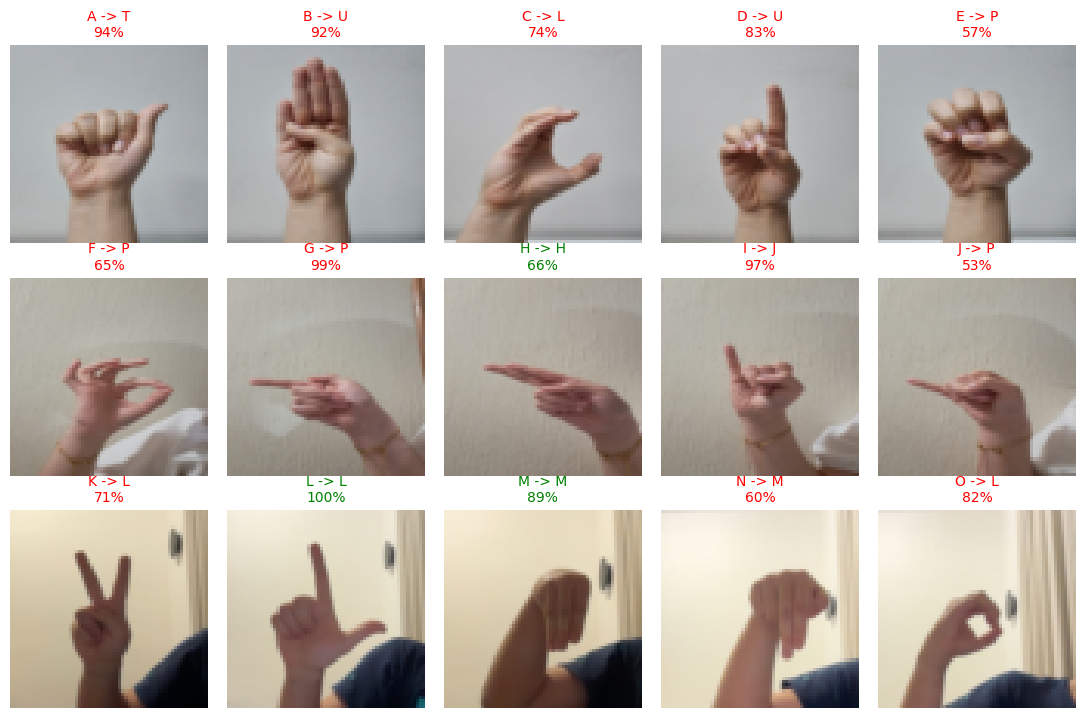

In [4]:
import matplotlib.pyplot as plt

n = len(imagenes)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
axes = axes.flatten()

for ax, arr, (_, fila) in zip(axes, imagenes, resultados.iterrows()):
    ax.imshow(arr, interpolation="nearest")
    color = "green" if fila["correcto"] else "red"
    ax.set_title(f"{fila['letra_real']} -> {fila['letra_predicha']}\n{fila['confianza']:.0%}", color=color, fontsize=10)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
accuracy_equipo = resultados["correcto"].mean()
print(f"Accuracy en fotos del equipo: {accuracy_equipo:.2%} ({resultados['correcto'].sum()}/{len(resultados)})")

resultados.groupby("integrante")["correcto"].agg(["sum", "count", "mean"])

Accuracy en fotos del equipo: 20.00% (3/15)


,sum,count,mean
integrante,,,
equipo,1,5,0.2
isa,0,5,0.0
nils,2,5,0.4


## Discusión

El modelo acertó solo 3 de 15 fotos, 20% de accuracy, muy por debajo del 98.66% que tiene en el test del propio dataset de Kaggle. Por integrante: Isa 0/5, el tercer integrante (fotos sin sufijo) 1/5, Nils 2/5.

La causa principal salta a la vista con solo ver las fotos al lado de las del dataset de entrenamiento. Las imágenes de Kaggle son casi cuadradas y la mano ocupa casi todo el cuadro, sin antebrazo ni fondo alrededor. Las fotos del equipo son verticales, tomadas con el celular a cierta distancia, con la mano ocupando una fracción chica del encuadre, antebrazo visible y bastante pared de fondo. Al forzar el resize a 64x64 cuadrado, esa foto vertical se aplasta y distorsiona las proporciones de la mano, y además la seña queda mucho más pequeña dentro de la imagen que lo que el modelo aprendió a reconocer. Es básicamente el mismo problema del zoom o el shift que se probó en el ejercicio 7, pero mucho más extremo y sin que el modelo lo haya visto en esa magnitud durante el entrenamiento.

Las letras con más confusión fueron señas de puño cerrado con detalles finos en la posición del pulgar o los dedos (A, D, K, O confundidas con T, U, L), que dependen de detalles pequeños que se pierden cuando la mano ocupa poco espacio en la imagen. En cambio, H, L y M sí se reconocieron bien, señas con dedos extendidos y una forma más clara que sigue siendo reconocible aunque la mano esté chica o algo distorsionada.

Esto conecta directo con el ejercicio 9: el dataset de Kaggle fue grabado en condiciones muy controladas y parecidas entre sí (mismo tipo de encuadre, cámara fija, mano llenando el cuadro), y un modelo entrenado solo con esas condiciones no generaliza bien a fotos tomadas de forma casual con un celular. Para un producto real como el de SignBridge, hace falta o pedirle al usuario que encuadre la mano de cierta forma, o detectar y recortar la mano automáticamente antes de pasarla al clasificador, o entrenar con datos que ya incluyan esa variedad de distancias y encuadres.